In [1]:
!python -m spacy download en_core_web_sm
!python -m spacy download de_core_news_sm
!pip uninstall torch torchtext -y
!pip install torch==2.2.2 torchtext==0.17.2 torchdata

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 77.9 MB/s eta 0:00:0000:010:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 77.2 MB/s eta 0:00:0000:010:01
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
   ━━━━━━━━━━━━━━━━━━━━

In [2]:
import math
import random
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils import clip_grad_norm_
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torch.utils.data import Dataset, DataLoader
from torchtext.data.functional import to_map_style_dataset
from torch.nn.functional import log_softmax
from torchtext.data.metrics import bleu_score

In [3]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Part 1: Scaled Dot Product

In [4]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self, d_model, dropout=0.1):
        super(ScaledDotProductAttention, self).__init__()
        self.d_model = d_model
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        batch_size, seq_len_q, d_k = query.size()

        # Compute attention scores: Q * K^T / sqrt(d_k)
        scores = torch.matmul(query, key.transpose(-2, -1)) / torch.sqrt(torch.tensor(d_k, dtype=torch.float32, device=query.device))

        # Apply mask if provided
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        # Apply softmax
        attention_weights = F.softmax(scores, dim=-1)
        attention_weights = self.dropout(attention_weights)

        output = torch.matmul(attention_weights, value)
        return output, attention_weights

# Part 2: Architecture Implementation

In [5]:
class AttentionEncoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers=1, dropout=0.1):
        super(AttentionEncoder, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embed_size)

        # LSTM layer
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers,
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)

        # Self-attention mechanism
        self.self_attention = ScaledDotProductAttention(hidden_size, dropout)

        # Linear projections for Q, K, V (following Bahdanau style)
        self.query_proj = nn.Linear(hidden_size, hidden_size)
        self.key_proj = nn.Linear(hidden_size, hidden_size)
        self.value_proj = nn.Linear(hidden_size, hidden_size)

        # Output projection
        self.output_proj = nn.Linear(hidden_size, hidden_size)

        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_lengths=None):
        # src: (batch_size, seq_len)
        # src_lengths: (batch_size,)
        batch_size, seq_len = src.size()

        # Embedding
        embedded = self.embedding(src)  # (batch_size, seq_len, embed_size)
        embedded = self.dropout(embedded)

        # LSTM encoding
        if src_lengths is not None:
            packed = nn.utils.rnn.pack_padded_sequence(embedded, src_lengths,
                                                     batch_first=True, enforce_sorted=False)
            lstm_out, hidden = self.lstm(packed)
            lstm_out, _ = nn.utils.rnn.pad_packed_sequence(lstm_out, batch_first=True)
        else:
            lstm_out, hidden = self.lstm(embedded)

        # lstm_out: (batch_size, seq_len, hidden_size)

        # Apply self-attention to LSTM outputs
        # Project to Q, K, V
        queries = self.query_proj(lstm_out)  # (batch_size, seq_len, hidden_size)
        keys = self.key_proj(lstm_out)       # (batch_size, seq_len, hidden_size)
        values = self.value_proj(lstm_out)   # (batch_size, seq_len, hidden_size)

        # Create attention mask for padding (if src_lengths provided)
        attention_mask = None
        if src_lengths is not None:
            attention_mask = self.create_padding_mask(src, src_lengths)

        # Apply self-attention
        attended_out, attention_weights = self.self_attention(queries, keys, values, attention_mask)

        # Residual connection + output projection
        encoder_outputs = self.output_proj(attended_out) + lstm_out
        encoder_outputs = self.dropout(encoder_outputs)

        return encoder_outputs, hidden, attention_weights

    def create_padding_mask(self, src, src_lengths):
        batch_size, seq_len = src.size()
        mask = torch.zeros(batch_size, seq_len, seq_len, device=src.device)

        for i, length in enumerate(src_lengths):
            # Mask positions beyond sequence length
            mask[i, :, length:] = 1
            mask[i, length:, :] = 1

        return mask.bool()

class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, encoder_hidden_size, num_layers=1, dropout=0.1):
        super(Decoder, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size + encoder_hidden_size, hidden_size, num_layers,
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)

        # Attention mechanism for encoder-decoder attention
        self.encoder_attention = ScaledDotProductAttention(hidden_size, dropout)
        self.query_proj = nn.Linear(hidden_size, hidden_size)

        self.output_proj = nn.Linear(hidden_size + encoder_hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt, encoder_outputs, hidden=None):
        # tgt: (batch_size, seq_len)
        # encoder_outputs: (batch_size, src_len, encoder_hidden_size)
        batch_size, seq_len = tgt.size()

        # Embedding
        embedded = self.embedding(tgt)
        embedded = self.dropout(embedded)

        outputs = []
        attention_weights_list = []

        for t in range(seq_len):
            # Current input
            current_input = embedded[:, t:t+1, :]  # (batch_size, 1, embed_size)

            # Query for attention (using current hidden state)
            if hidden is not None:
                query = self.query_proj(hidden[0][-1:].transpose(0, 1))  # (batch_size, 1, hidden_size)
            else:
                query = torch.zeros(batch_size, 1, self.hidden_size, device=tgt.device)

            # Attend to encoder outputs
            context, attn_weights = self.encoder_attention(
                query, encoder_outputs, encoder_outputs
            )
            attention_weights_list.append(attn_weights)

            # Concatenate input with context
            lstm_input = torch.cat([current_input, context], dim=-1)

            # LSTM step
            lstm_out, hidden = self.lstm(lstm_input, hidden)

            # Output projection
            combined = torch.cat([lstm_out, context], dim=-1)
            output = self.output_proj(combined)
            outputs.append(output)

        outputs = torch.cat(outputs, dim=1)  # (batch_size, seq_len, vocab_size)
        attention_weights = torch.cat(attention_weights_list, dim=1)

        return outputs, hidden, attention_weights

class Seq2Seq(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, embed_size=256,
                 hidden_size=512, num_layers=1, dropout=0.1):
        super(Seq2Seq, self).__init__()

        self.encoder = AttentionEncoder(src_vocab_size, embed_size, hidden_size,
                                      num_layers, dropout)
        self.decoder = Decoder(tgt_vocab_size, embed_size, hidden_size,
                                   hidden_size, num_layers, dropout)

    def forward(self, src, tgt, src_lengths=None):
        # Encode
        encoder_outputs, encoder_hidden, encoder_attention = self.encoder(src, src_lengths)

        # Decode
        decoder_outputs, decoder_hidden, decoder_attention = self.decoder(
            tgt, encoder_outputs, encoder_hidden
        )

        return {
            'decoder_outputs': decoder_outputs,
            'encoder_attention': encoder_attention,
            'decoder_attention': decoder_attention,
            'encoder_outputs': encoder_outputs
        }

# Part 3: Run


Data from a GitHub Repo: https://github.com/multi30k/dataset

In [5]:
!unzip multi30k.zip

Archive:  multi30k.zip
  inflating: train.de                
  inflating: train.en                
  inflating: val.de                  
  inflating: val.en                  


In [6]:
def load_dataset(split='train'):
    src_path = f"{split}.en"
    tgt_path = f"{split}.de"

    with open(src_path, encoding="utf-8") as f_src, open(tgt_path, encoding="utf-8") as f_tgt:
        src_lines = [line.strip() for line in f_src]
        tgt_lines = [line.strip() for line in f_tgt]

    assert len(src_lines) == len(tgt_lines)
    return list(zip(src_lines, tgt_lines))

train_data = load_dataset("train")
val_data = load_dataset("val")

In [7]:
train_data[0]

('Two young, White males are outside near many bushes.',
 'Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.')

In [8]:
SRC_LANGUAGE = "en"
TGT_LANGUAGE = "de"

token_transform = {
    SRC_LANGUAGE: get_tokenizer("spacy", language="en_core_web_sm"),
    TGT_LANGUAGE: get_tokenizer("spacy", language="de_core_news_sm")
}

specials = ["<pad>", "<unk>", "<bos>", "<eos>"]

def yield_tokens(data, language):
    for src, tgt in data:
        text = src if language == SRC_LANGUAGE else tgt
        yield token_transform[language](text)

# Build vocab
vocab_transform = {
    SRC_LANGUAGE: build_vocab_from_iterator(yield_tokens(train_data, SRC_LANGUAGE), specials=specials),
    TGT_LANGUAGE: build_vocab_from_iterator(yield_tokens(train_data, TGT_LANGUAGE), specials=specials)
}

for vocab in vocab_transform.values():
    vocab.set_default_index(vocab["<unk>"])

PAD_IDX = vocab_transform[TGT_LANGUAGE]["<pad>"]
BOS_IDX = vocab_transform[TGT_LANGUAGE]["<bos>"]
EOS_IDX = vocab_transform[TGT_LANGUAGE]["<eos>"]

In [9]:
def collate_batch(batch):
    src_batch, tgt_batch, src_lengths = [], [], []

    for src_sample, tgt_sample in batch:
        src_tokens = [BOS_IDX] + vocab_transform[SRC_LANGUAGE](token_transform[SRC_LANGUAGE](src_sample)) + [EOS_IDX]
        tgt_tokens = [BOS_IDX] + vocab_transform[TGT_LANGUAGE](token_transform[TGT_LANGUAGE](tgt_sample)) + [EOS_IDX]
        src_batch.append(torch.tensor(src_tokens, dtype=torch.long))
        tgt_batch.append(torch.tensor(tgt_tokens, dtype=torch.long))
        src_lengths.append(len(src_tokens))

    src_batch = nn.utils.rnn.pad_sequence(src_batch, padding_value=PAD_IDX, batch_first=True)
    tgt_batch = nn.utils.rnn.pad_sequence(tgt_batch, padding_value=PAD_IDX, batch_first=True)
    src_lengths = torch.tensor(src_lengths)

    return src_batch, tgt_batch, src_lengths

In [10]:
class TranslationDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __getitem__(self, idx):
        return self.data[idx]

    def __len__(self):
        return len(self.data)

BATCH_SIZE = 32

train_dataset = TranslationDataset(train_data)
val_dataset = TranslationDataset(val_data)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

In [41]:
def train(model, dataloader, optimizer, criterion, clip=1.0):
    model.train()
    epoch_loss = 0
    for src, tgt, src_lengths in tqdm(dataloader, desc="Training", leave=False):
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        optimizer.zero_grad()
        output = model(src, tgt[:, :-1], src_lengths)['decoder_outputs']
        output = output.reshape(-1, output.shape[-1])
        tgt = tgt[:, 1:].reshape(-1)
        loss = criterion(output, tgt)
        loss.backward()
        clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(dataloader)

def evaluate(model, dataloader, criterion):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for src, tgt, src_lengths in tqdm(dataloader, desc="Evaluating", leave=False):
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            output = model(src, tgt[:, :-1], src_lengths)['decoder_outputs']
            output = output.reshape(-1, output.shape[-1])
            tgt = tgt[:, 1:].reshape(-1)
            loss = criterion(output, tgt)
            epoch_loss += loss.item()
    return epoch_loss / len(dataloader)

def translate_batch(model, src, src_lengths, max_len=50):
    model.eval()
    with torch.no_grad():
        src = src.to(DEVICE)
        batch_size = src.size(0)
        outputs = torch.full((batch_size, 1), BOS_IDX, dtype=torch.long).to(DEVICE)
        encoder_outputs, hidden, _ = model.encoder(src, src_lengths)
        for _ in range(max_len):
            out = model.decoder(outputs, encoder_outputs, hidden)
            logits = out[0][:, -1, :]
            next_token = logits.argmax(dim=-1).unsqueeze(1)
            outputs = torch.cat((outputs, next_token), dim=1)
        return outputs[:, 1:]  # remove BOS

def compute_bleu(model, dataloader):
    targets, predictions = [], []
    for src, tgt, src_lengths in tqdm(dataloader, desc="BLEU Eval", leave=False):
        output = translate_batch(model, src, src_lengths)
        for pred, gold in zip(output, tgt):
            pred_tokens = [vocab_transform[TGT_LANGUAGE].lookup_token(idx.item()) for idx in pred if idx != PAD_IDX and idx != EOS_IDX]
            tgt_tokens = [vocab_transform[TGT_LANGUAGE].lookup_token(idx.item()) for idx in gold if idx != PAD_IDX and idx != BOS_IDX and idx != EOS_IDX]
            if tgt_tokens:
                predictions.append(pred_tokens)
                targets.append([tgt_tokens])
    return bleu_score(predictions, targets) * 100

In [42]:
SRC_VOCAB_SIZE = len(vocab_transform[SRC_LANGUAGE])
TGT_VOCAB_SIZE = len(vocab_transform[TGT_LANGUAGE])
EMBED_SIZE = 256
HIDDEN_SIZE = 512
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = Seq2Seq(SRC_VOCAB_SIZE, TGT_VOCAB_SIZE, EMBED_SIZE, HIDDEN_SIZE).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

Epoch 1:	 Train Loss: 3.422, Val Loss: 2.511, BLEU: 9.35
Best model saved!


Epoch 2:	 Train Loss: 2.003, Val Loss: 2.235, BLEU: 13.41
Best model saved!


Epoch 3:	 Train Loss: 1.332, Val Loss: 2.210, BLEU: 14.58
Best model saved!


Epoch 4:	 Train Loss: 0.943, Val Loss: 2.235, BLEU: 14.87
Best model saved!


Epoch 5:	 Train Loss: 0.736, Val Loss: 2.299, BLEU: 14.66


...

Epoch 16:	 Train Loss: 0.184, Val Loss: 2.899, BLEU: 12.88


Epoch 17:	 Train Loss: 0.176, Val Loss: 2.917, BLEU: 12.44


Epoch 18:	 Train Loss: 0.166, Val Loss: 2.987, BLEU: 12.73


Epoch 19:	 Train Loss: 0.161, Val Loss: 3.043, BLEU: 12.32


Epoch 20:	 Train Loss: 0.152, Val Loss: 3.049, BLEU: 14.45


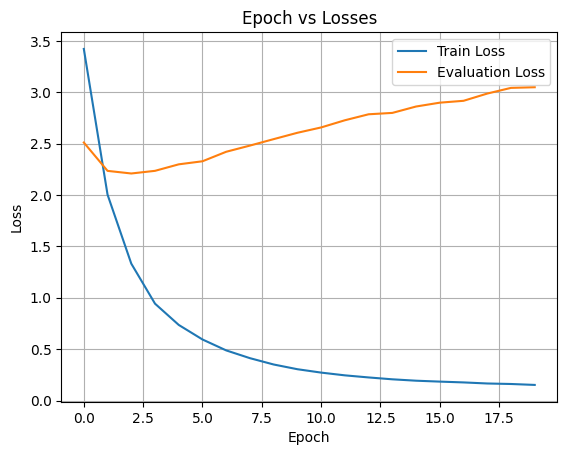

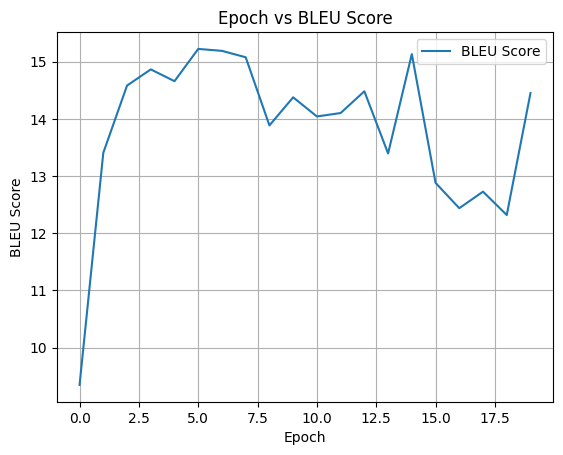

<Figure size 640x480 with 0 Axes>

In [43]:
epochs = 20
best_val_bleu = 0
SAVE_PATH = "seq2seq_best.pt"

train_losses, val_losses, bleu_scores = [], [], []

for epoch in range(epochs):
    train_loss = train(model, train_dataloader, optimizer, criterion)
    val_loss = evaluate(model, val_dataloader, criterion)
    bleu = compute_bleu(model, val_dataloader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    bleu_scores.append(bleu)

    print(f"Epoch {epoch+1}:\t Train Loss: {train_loss:.3f}, Val Loss: {val_loss:.3f}, BLEU: {bleu:.2f}")

    if bleu > best_val_bleu:
        best_val_bleu = bleu
        torch.save(model.state_dict(), SAVE_PATH)
        print("Best model saved!")

torch.save(model.state_dict(), "seq2seq_final.pt")

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Evaluation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs Losses")
plt.grid(True)
plt.legend()
plt.savefig("seq2seq_losses.png")
plt.show()
plt.clf()

plt.plot(bleu_scores, label="BLEU Score")
plt.xlabel("Epoch")
plt.ylabel("BLEU Score")
plt.title("Epoch vs BLEU Score")
plt.grid(True)
plt.legend()
plt.savefig("seq2seq_bleu_scores.png")
plt.show()
plt.clf()

In [15]:
def example(model, dataloader, max_len=50):
    for i, (src, tgt, src_lengths) in enumerate(dataloader):
        if i >= 1:
            break
        model.eval()
        with torch.no_grad():
            src = src.to(DEVICE)
            batch_size = src.size(0)
            outputs = torch.full((batch_size, 1), BOS_IDX, dtype=torch.long).to(DEVICE)
            encoder_outputs, hidden, _ = model.encoder(src, src_lengths)
            for _ in range(max_len):
                out = model.decoder(outputs, encoder_outputs, hidden)
                logits = out[0][:, -1, :]
                next_token = logits.argmax(dim=-1).unsqueeze(1)
                outputs = torch.cat((outputs, next_token), dim=1)

        output = outputs
        predictions, originals, targets = [], [], []
        for i, (pred, s, gold) in enumerate(zip(output, src, tgt)):
            pred_tokens = [vocab_transform[TGT_LANGUAGE].lookup_token(idx.item()) for idx in pred if idx != PAD_IDX and idx != EOS_IDX]
            src_tokens = [vocab_transform[SRC_LANGUAGE].lookup_token(idx.item()) for idx in s if idx != PAD_IDX and idx != BOS_IDX and idx != EOS_IDX]
            tgt_tokens = [vocab_transform[TGT_LANGUAGE].lookup_token(idx.item()) for idx in gold if idx != PAD_IDX and idx != BOS_IDX and idx != EOS_IDX]
            if tgt_tokens:
                predictions.append(pred_tokens)
                originals.append(src_tokens)
                targets.append(tgt_tokens)
            if i >= 2: break

        print("="*80)
        print("TRANSLATION EXAMPLES")
        print("="*80)

        for i, (s, p, t) in enumerate(zip(originals, predictions, targets)):
            print(f"\nExample {i+1}:")
            print(f"Original (en): {' '.join(s[1:])}")
            print(f"Target (de):   {' '.join(t[1:])}")
            print(f"Predicted:     {' '.join(p[1:])}")
            print()

        print("\n" + "="*80)
        
SRC_VOCAB_SIZE = len(vocab_transform[SRC_LANGUAGE])
TGT_VOCAB_SIZE = len(vocab_transform[TGT_LANGUAGE])
EMBED_SIZE = 256
HIDDEN_SIZE = 512
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = Seq2Seq(SRC_VOCAB_SIZE, TGT_VOCAB_SIZE, EMBED_SIZE, HIDDEN_SIZE).to(DEVICE)
loaded_state_dict = torch.load("seq2seq_best.pt", map_location=DEVICE)
model.load_state_dict(loaded_state_dict)

example(model, train_dataloader)

TRANSLATION EXAMPLES

Example 1:
Original (en): women learning from a man how to make fabric .
Target (de):   Inderin lernt von einem Mann , wie man Stoff herstellt .
Predicted:     Eine Inderin lernt von einem Mann , der wie man herstellt herstellt . herstellt . herstellt . herstellt . herstellt . herstellt . herstellt . herstellt . . . herstellt .


Example 2:
Original (en): crowd of various people walking through a marketplace .
Target (de):   verschiedene Menschen laufen über einen Marktplatz .
Predicted:     Viele verschiedene Menschen laufen durch eine Marktplatz . . . gehen . gehen . gehen . gehen . gehen . gehen . gehen .


Example 3:
Original (en): man with hairy arms and a watch pours creamer into a cup of coffee , making color ripples along the surface .
Target (de):   Mann mit behaarten Armen und einer Uhr gießt Milchschaum in eine Kaffeetasse , wodurch an der Oberfläche bunte Wellen entstehen .
Predicted:     Ein Mann mit behaarten Armen und Uhr gießt Milchschaum in eine K

# Part 4: Transformer

In [36]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        
    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
            
        attention_weights = F.softmax(scores, dim=-1)
        output = torch.matmul(attention_weights, V)
        return output
    
    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)
        
        # Linear projections
        Q = self.W_q(query)
        K = self.W_k(key)
        V = self.W_v(value)
        
        # Reshape for multi-head attention
        Q = Q.view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        
        # Apply attention
        attention = self.scaled_dot_product_attention(Q, K, V, mask)
        
        # Concatenate heads
        attention = attention.transpose(1, 2).contiguous().view(
            batch_size, -1, self.d_model)
        
        # Final linear projection
        output = self.W_o(attention)
        return output

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * 
                           (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        return x + self.pe[:x.size(0), :]

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        
    def forward(self, x):
        return self.linear2(F.relu(self.linear1(x)))

class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attention = MultiHeadAttention(d_model, n_heads)
        self.feed_forward = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask=None):
        # Self-attention with residual connection and layer norm
        attn_output = self.self_attention(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        
        # Feed forward with residual connection and layer norm
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))
        
        return x

class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attention = MultiHeadAttention(d_model, n_heads)
        self.cross_attention = MultiHeadAttention(d_model, n_heads)
        self.feed_forward = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, encoder_output, src_mask=None, tgt_mask=None):
        # Self-attention on target sequence
        attn_output = self.self_attention(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_output))
        
        # Cross-attention with encoder output
        attn_output = self.cross_attention(x, encoder_output, encoder_output, src_mask)
        x = self.norm2(x + self.dropout(attn_output))
        
        # Feed forward
        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout(ff_output))
        
        return x

class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout) 
            for _ in range(n_layers)
        ])
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask=None):
        # Embedding and positional encoding
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.pos_encoding(x.transpose(0, 1)).transpose(0, 1)
        x = self.dropout(x)
        
        # Pass through encoder layers
        for layer in self.layers:
            x = layer(x, mask)
            
        return x

class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, max_len, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout) 
            for _ in range(n_layers)
        ])
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, encoder_output, src_mask=None, tgt_mask=None):
        # Embedding and positional encoding
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.pos_encoding(x.transpose(0, 1)).transpose(0, 1)
        x = self.dropout(x)
        
        # Pass through decoder layers
        for layer in self.layers:
            x = layer(x, encoder_output, src_mask, tgt_mask)
            
        return x

class SimplifiedTransformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=64, n_heads=2, 
                 n_layers=2, d_ff=128, max_len=100, dropout=0.1):
        super().__init__()
        
        self.encoder = TransformerEncoder(src_vocab_size, d_model, n_heads, 
                                        n_layers, d_ff, max_len, dropout)
        self.decoder = TransformerDecoder(tgt_vocab_size, d_model, n_heads, 
                                        n_layers, d_ff, max_len, dropout)
        self.output_projection = nn.Linear(d_model, tgt_vocab_size)
        
    def create_padding_mask(self, x, pad_token=0):
        return (x != pad_token).unsqueeze(1).unsqueeze(2)
    
    def create_look_ahead_mask(self, size):
        mask = torch.triu(torch.ones(size, size), diagonal=1)
        return mask == 0
    
    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        # Create masks if not provided
        if src_mask is None:
            src_mask = self.create_padding_mask(src).to(src.device)
        if tgt_mask is None:
            tgt_padding_mask = self.create_padding_mask(tgt).to(tgt.device)
            tgt_look_ahead_mask = self.create_look_ahead_mask(tgt.size(1)).to(tgt.device)
            tgt_mask = tgt_padding_mask & tgt_look_ahead_mask
        
        # Encode source sequence
        encoder_output = self.encoder(src, src_mask)
        
        # Decode target sequence
        decoder_output = self.decoder(tgt, encoder_output, src_mask, tgt_mask)
        
        # Project to vocabulary
        output = self.output_projection(decoder_output)
        
        return output

# Training Loop with Model Saving
def train_model(model, train_loader, validation_loader, vocab_transform, token_transform, 
                src_language, tgt_language, pad_idx, bos_idx, eos_idx, epochs=10, lr=0.001,
                save_dir="", model_name="simplified_transformer"):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
    
    # Initialize best BLEU score tracking
    best_bleu = 0.0
    best_epoch = 0
    
    # Lists to store training history
    train_losses = []
    val_losses = []
    bleu_scores = []
    
    print(f"Training ...")
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        total_train_loss = 0
        train_batch_count = 0
        
        # Training progress bar
        train_pbar = tqdm(train_loader, desc='Training', leave=False)
        
        for batch_idx, batch_data in enumerate(train_pbar):
            # Handle the 3-item tuple from your collate function
            if len(batch_data) == 3:
                src, tgt, src_lengths = batch_data
            else:
                src, tgt = batch_data
            
            src, tgt = src.to(device), tgt.to(device)
            
            # Teacher forcing: use target input (all tokens except last)
            tgt_input = tgt[:, :-1]
            tgt_output = tgt[:, 1:]
            
            optimizer.zero_grad()
            
            # Forward pass
            output = model(src, tgt_input)
            
            # Calculate loss
            loss = criterion(output.reshape(-1, output.size(-1)), 
                           tgt_output.reshape(-1))
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            total_train_loss += loss.item()
            train_batch_count += 1
        
        avg_train_loss = total_train_loss / train_batch_count
        
        # Validation phase
        model.eval()
        total_val_loss = 0
        val_batch_count = 0
        
        # Validation progress bar
        val_pbar = tqdm(validation_loader, desc=f'Validation', leave=False)
        
        with torch.no_grad():
            for batch_data in val_pbar:
                # Handle the 3-item tuple from your collate function
                if len(batch_data) == 3:
                    src, tgt, src_lengths = batch_data
                else:
                    src, tgt = batch_data
                
                src, tgt = src.to(device), tgt.to(device)
                
                # For validation loss calculation
                tgt_input = tgt[:, :-1]
                tgt_output = tgt[:, 1:]
                
                output = model(src, tgt_input)
                val_loss = criterion(output.reshape(-1, output.size(-1)), 
                                   tgt_output.reshape(-1))
                
                total_val_loss += val_loss.item()
                val_batch_count += 1
        
        avg_val_loss = total_val_loss / val_batch_count
        
        # Efficient BLEU Score Calculation
        bleu = compute_bleu(
            model, validation_loader, vocab_transform, tgt_language,
            bos_idx, eos_idx, pad_idx, device
        )
        
        # Store training history
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        bleu_scores.append(bleu)
        
        # Print epoch results
        print(f'Epoch {epoch+1}/{epochs}: \t Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, BLEU: {bleu:.4f}')
       
        # Check if this is the best model so far
        if bleu > best_bleu:
            best_bleu = bleu
            
            # Save best model
            best_model_path = os.path.join(save_dir, f"{model_name}_best.pth")
            torch.save(model.state_dict(), best_model_path)
            
            print("Best model saved!")
        
    
    # Save final model (last epoch)
    final_model_path = os.path.join(save_dir, f"{model_name}_final.pth")
    torch.save(model.state_dict(), final_model_path)

    plot_training_history(train_losses, val_losses, bleu_scores)

# Function to load a saved model
def load_model(model_path, device='cuda'):
    checkpoint = torch.load(model_path, map_location=device)
    
    # Extract model configuration
    config = checkpoint['model_config']
    
    # Create model with saved configuration
    model = SimplifiedTransformer(
        src_vocab_size=config['src_vocab_size'],
        tgt_vocab_size=config['tgt_vocab_size'],
        d_model=config['d_model'],
        n_heads=config['n_heads'],
        n_layers=config['n_layers'],
        d_ff=config['d_ff']
    )
    
    # Load model weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)

    print("Loaded model successfully!")
    
    return model, checkpoint

# Function to plot training history
def plot_training_history(train_losses, val_losses, bleu_scores, save_dir=None):
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Evaluation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Epoch vs Losses")
    plt.grid(True)
    plt.legend()
    plt.savefig("simplified_transformer_losses.png")
    plt.show()
    plt.clf()
    
    plt.plot(bleu_scores, label="BLEU Score")
    plt.xlabel("Epoch")
    plt.ylabel("BLEU Score")
    plt.title("Epoch vs BLEU Score")
    plt.grid(True)
    plt.legend()
    plt.savefig("simplified_transformer_bleu_scores.png")
    plt.show()
    plt.clf()

def translate_batch(model, src, bos_idx, eos_idx, pad_idx, device, max_len=50):
    model.eval()
    with torch.no_grad():
        src = src.to(device)
        batch_size = src.size(0)
        
        # Initialize outputs with BOS token
        outputs = torch.full((batch_size, 1), bos_idx, dtype=torch.long).to(device)
        finished = torch.zeros(batch_size, dtype=torch.bool).to(device)
        
        for _ in range(max_len):
            logits = model(src, outputs)
            next_tokens = logits[:, -1, :].argmax(dim=-1).unsqueeze(1)
            next_tokens = torch.where(finished.unsqueeze(1), pad_idx, next_tokens)
            outputs = torch.cat((outputs, next_tokens), dim=1)
            finished = finished | (next_tokens.squeeze(1) == eos_idx)
            
            if finished.all():
                break
        
        return outputs[:, 1:]  # Remove BOS token

def compute_bleu(model, dataloader, vocab_transform, tgt_language, 
                          bos_idx, eos_idx, pad_idx, device):
    model.eval()
    targets, predictions = [], []
    
    bleu_pbar = tqdm(dataloader, desc="BLEU Evaluation", leave=False, dynamic_ncols=True)
    
    with torch.no_grad():
        for batch_data in bleu_pbar:
            if len(batch_data) == 3:
                src, tgt, src_lengths = batch_data
            else:
                src, tgt = batch_data
            
            # Batch translate
            output = translate_batch(model, src, bos_idx, eos_idx, pad_idx, device)
            
            # Convert predictions and targets to tokens
            for pred, gold in zip(output, tgt):
                # Convert prediction indices to tokens
                pred_tokens = [vocab_transform[tgt_language].lookup_token(idx.item()) 
                              for idx in pred if idx != pad_idx and idx != eos_idx]
                
                # Convert target indices to tokens  
                tgt_tokens = [vocab_transform[tgt_language].lookup_token(idx.item()) 
                             for idx in gold if idx != pad_idx and idx != bos_idx and idx != eos_idx]
                
                if tgt_tokens:
                    predictions.append(pred_tokens)
                    targets.append([tgt_tokens])
            
    # Calculate BLEU score
    if predictions and targets:
        return bleu_score(predictions, targets) * 100
    else:
        return 0.0

def translate_sentence(model, sentence, vocab_transform, token_transform, src_language, tgt_language, 
                      bos_idx, eos_idx, device, max_len=50):
    model.eval()
    
    src_vocab = vocab_transform[src_language]
    tgt_vocab = vocab_transform[tgt_language]
    
    # Tokenize input sentence using your tokenizer
    src_tokens = [bos_idx] + src_vocab(token_transform[src_language](sentence)) + [eos_idx]
    src_tensor = torch.LongTensor([src_tokens]).to(device)

    output = translate_batch(model, src_tensor, bos_idx, eos_idx, vocab_transform[tgt_language]["<pad>"], device, max_len)
    
    # Convert tokens back to words
    translated_words = [tgt_vocab.lookup_token(token.item()) 
                       for token in output[0] if token != vocab_transform[tgt_language]["<pad>"] and token != eos_idx]
    
    return ' '.join(translated_words)

def print_translation_examples(model, test_data, vocab_transform, token_transform, 
                              src_language, tgt_language, bos_idx, eos_idx, device, num_examples=3):
    model.eval()
    
    print("="*80)
    print("TRANSLATION EXAMPLES")
    print("="*80)
    
    for i in range(min(num_examples, len(test_data))):
        src_sentence, tgt_sentence = test_data[i]
        
        # Get model prediction
        predicted_sentence = translate_sentence(
            model, src_sentence, vocab_transform, token_transform, 
            src_language, tgt_language, bos_idx, eos_idx, device
        )
        
        print(f"\nExample {i+1}:")
        print(f"Original (en): {src_sentence}")
        print(f"Target (de):   {tgt_sentence}")
        print(f"Predicted:     {predicted_sentence}")
        print()
    
    print("\n" + "="*80)

Training ...


Epoch 1/20: 	 Train Loss: 4.6282, Val Loss: 3.8456, BLEU: 8.7241
Best model saved!


Epoch 2/20: 	 Train Loss: 3.5544, Val Loss: 3.4653, BLEU: 11.0630
Best model saved!


Epoch 3/20: 	 Train Loss: 3.1448, Val Loss: 3.1957, BLEU: 13.7358
Best model saved!


Epoch 4/20: 	 Train Loss: 2.8644, Val Loss: 3.0776, BLEU: 15.8716
Best model saved!


...

Epoch 16/20: 	 Train Loss: 1.6140, Val Loss: 2.9569, BLEU: 22.2841
Best model saved!


Epoch 17/20: 	 Train Loss: 1.5811, Val Loss: 2.9807, BLEU: 21.5908


Epoch 18/20: 	 Train Loss: 1.5455, Val Loss: 3.0084, BLEU: 22.4299
Best model saved!


Epoch 19/20: 	 Train Loss: 1.5142, Val Loss: 2.9814, BLEU: 22.6114
Best model saved!


Epoch 20/20: 	 Train Loss: 1.4882, Val Loss: 2.9967, BLEU: 22.6138
Best model saved!


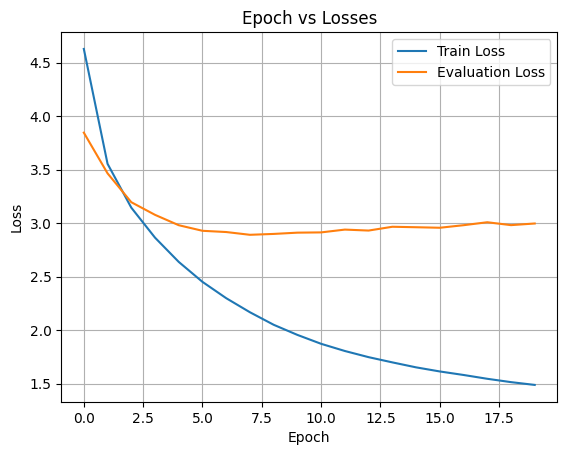

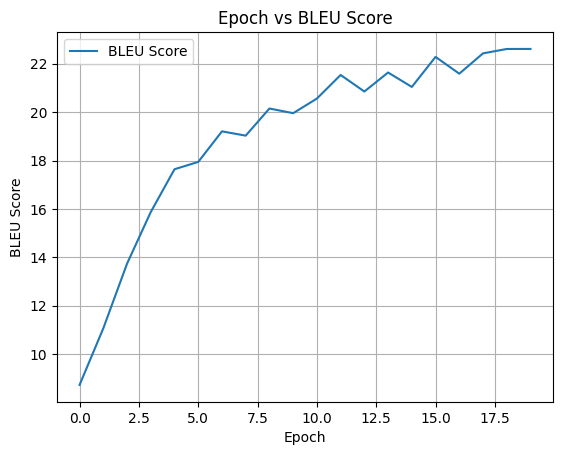

<Figure size 640x480 with 0 Axes>

In [37]:
SRC_LANGUAGE = "en"  # German source
TGT_LANGUAGE = "de"  # English target
SRC_VOCAB_SIZE = len(vocab_transform[SRC_LANGUAGE])
TGT_VOCAB_SIZE = len(vocab_transform[TGT_LANGUAGE])
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Your special token indices
PAD_IDX = vocab_transform[TGT_LANGUAGE]["<pad>"]
BOS_IDX = vocab_transform[TGT_LANGUAGE]["<bos>"]
EOS_IDX = vocab_transform[TGT_LANGUAGE]["<eos>"]

# Create model with simplified transformer architecture
model = SimplifiedTransformer(
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    d_model=64,           # Reduced from 512
    n_heads=2,            # Reduced from 8
    n_layers=2,           # Reduced from 6
    d_ff=128,             # Reduced from 2048
    max_len=100,
    dropout=0.1
).to(DEVICE)

# Train model with validation and BLEU score
train_model(
    model=model, 
    train_loader=train_dataloader,
    validation_loader=val_dataloader,
    vocab_transform=vocab_transform,
    token_transform=token_transform,
    src_language=SRC_LANGUAGE,
    tgt_language=TGT_LANGUAGE,
    pad_idx=PAD_IDX,
    bos_idx=BOS_IDX,
    eos_idx=EOS_IDX,
    epochs=20, 
    lr=1e-3
)

In [38]:
# Show examples using validation data
print_translation_examples(
    model=model, 
    test_data=val_data[:10],  # Use first 10 validation examples
    vocab_transform=vocab_transform,
    token_transform=token_transform,
    src_language=SRC_LANGUAGE,
    tgt_language=TGT_LANGUAGE,
    bos_idx=BOS_IDX,
    eos_idx=EOS_IDX,
    device=DEVICE
)

TRANSLATION EXAMPLES

Example 1:
Original (EN): A group of men are loading cotton onto a truck
Target (DE):   Eine Gruppe von Männern lädt Baumwolle auf einen Lastwagen
Predicted:     Eine Gruppe Männer startet eine Wohnung auf .


Example 2:
Original (EN): A man sleeping in a green room on a couch.
Target (DE):   Ein Mann schläft in einem grünen Raum auf einem Sofa.
Predicted:     Ein Mann in einem grünen Zimmer schläft auf einem Sofa .


Example 3:
Original (EN): A boy wearing headphones sits on a woman's shoulders.
Target (DE):   Ein Junge mit Kopfhörern sitzt auf den Schultern einer Frau.
Predicted:     Ein Junge mit Kopfhörern sitzt auf einer Frau .


